#### Python programming for business intelligence

##### Final Project

Matias Wahlstedt

#### Statement of AI use:

- Mostly used for troubleshooting existing code, after general googling, looking at course material or looking up alternative solutions on forums such as stackoverflow
- Also used for idea and project structure setup 

### Salary Analysis using Python and Ollama-Based Job Classification

The goal of this project is to analyse which job-related factors are associated with the salary levels in the job salary dataset. The project uses Python for data import, cleaning, visual analysis, regressions and exporting. In addition, a local Ollama LLM is used as an API to classify job roles into broader categories.

##### The main research question for this project is:

Which job-related factors are associated with salary differences in the dataset?

#### How to run the notebook:

1. Place the salary dataset CSV file in the same folder as this notebook.
2. Install the required packages: pandas, numpy, matplotlib, seaborn, openai and statsmodels.
3. Install Ollama from https://ollama.com/.
4. Download the local model used in this project by running `ollama pull gemma3:4b` in the terminal.
5. Make sure Ollama is running locally.
6. Run the notebook from top to bottom.

#### Pipeline image

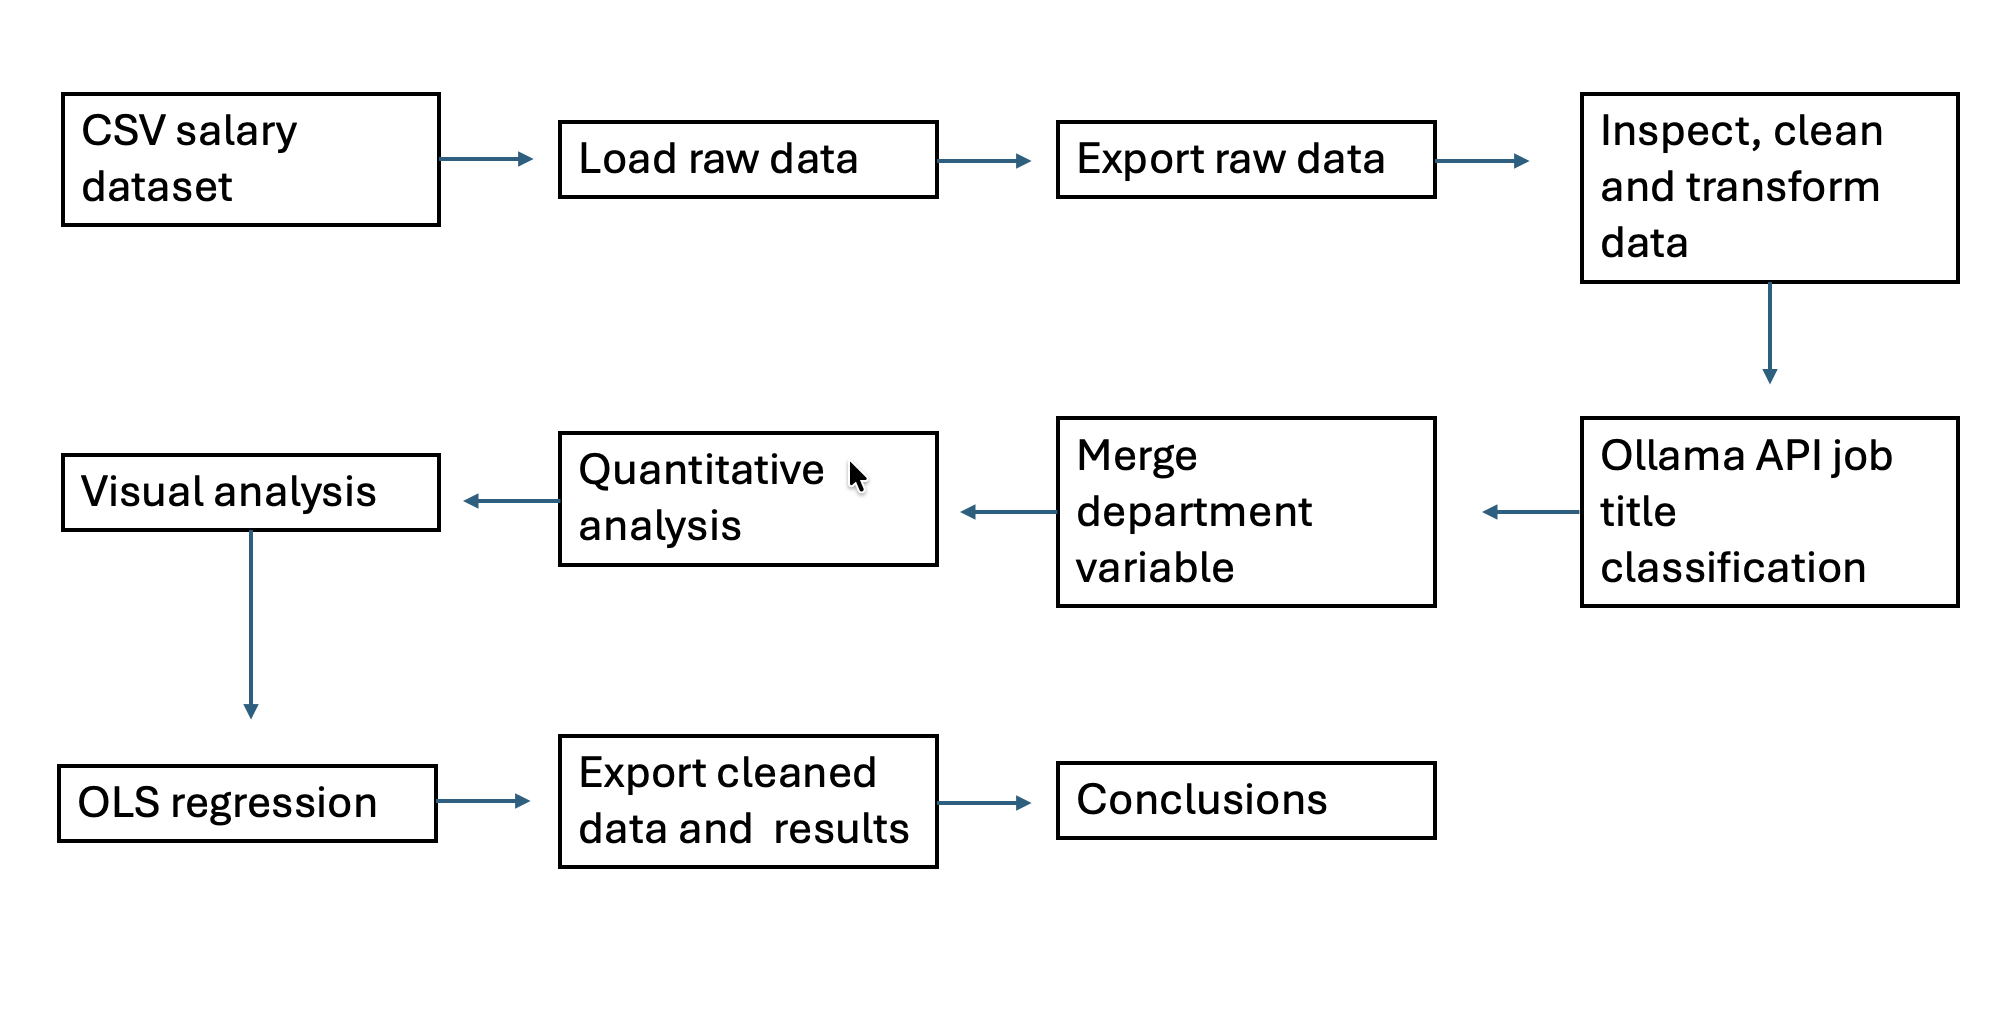

#### 1) Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from openai import OpenAI

import statsmodels.api as sm
import statsmodels.formula.api as smf

#### 2) Load & export raw data

In [2]:
raw_df = pd.read_csv("job_salary_predictions.csv")
raw_df.head()

,job title,experience years,education level,skills count,Industry,company size,Location,remote work,Certifications,Salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [3]:
raw_df.to_csv("raw_job_salary_data.csv", index=False)

In [4]:
#If the original file is not available, the reviewer can load the exported raw data:
# raw_df = pd.read_csv("raw_job_salary_data.csv")

In [5]:
df = raw_df.copy()
df.head()

,job title,experience years,education level,skills count,Industry,company size,Location,remote work,Certifications,Salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


#### 3) Initial data inspection

In [6]:
# basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job title         250000 non-null  object
 1   experience years  250000 non-null  int64 
 2   education level   250000 non-null  object
 3   skills count      250000 non-null  int64 
 4   Industry          250000 non-null  object
 5   company size      250000 non-null  object
 6   Location          250000 non-null  object
 7   remote work       250000 non-null  object
 8   Certifications    250000 non-null  int64 
 9   Salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB


In [7]:
# nr. of duplicated rows
print("duplicated rows:", df.duplicated().sum())

duplicated rows: 0


In [8]:
# nr. of NA:s
df.isna().sum()

job title           0
experience years    0
education level     0
skills count        0
Industry            0
company size        0
Location            0
remote work         0
Certifications      0
Salary              0
dtype: int64

In [9]:
# descriptives
df.describe()

,experience years,skills count,Certifications,Salary
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,10.005408,9.997812,2.491928,145718.080524
std,6.060602,5.479288,1.706475,37407.952729
min,0.000000,1.000000,0.000000,31867.000000
25%,5.000000,5.000000,1.000000,119358.000000
50%,10.000000,10.000000,2.000000,143453.000000
75%,15.000000,15.000000,4.000000,169492.000000
max,20.000000,19.000000,5.000000,333046.000000


In [10]:
# distribution of object variables
for column in df.select_dtypes(include="object").columns:
    print(df[column].value_counts())
    print()

job title
Backend Developer            21125
Cybersecurity Analyst        20959
Product Manager              20950
AI Engineer                  20945
Data Scientist               20890
DevOps Engineer              20889
Software Engineer            20876
Data Analyst                 20722
Cloud Engineer               20686
Machine Learning Engineer    20677
Business Analyst             20648
Frontend Developer           20633
Name: count, dtype: int64

education level
Master         50352
High School    50065
Bachelor       49950
PhD            49857
Diploma        49776
Name: count, dtype: int64

Industry
Finance          25393
Consulting       25258
Media            25034
Manufacturing    25024
Technology       24903
Government       24901
Healthcare       24898
Education        24889
Telecom          24859
Retail           24841
Name: count, dtype: int64

company size
Large         50254
Small         50235
Medium        50027
Enterprise    49875
Startup       49609
Name: count, dty

#### 4) Cleaning and transforming data

- The dataset does not contain missing values or duplicate rows, so this first part focuses mostly on standardising column names, creating new variables and preparing the data for main analysis.
- The second part includes the Ollama LLM used through an API to categorise the job titles into broader groups, used later in the project. 


#### 4.1) Data transformation

In [11]:
df.columns

Index(['job title', 'experience years', 'education level', 'skills count',
       'Industry', 'company size', 'Location', 'remote work', 'Certifications',
       'Salary'],
      dtype='object')

In [12]:
# Standardise column names

df.columns = df.columns.str.lower().str.replace (" ","_")
df.columns

Index(['job_title', 'experience_years', 'education_level', 'skills_count',
       'industry', 'company_size', 'location', 'remote_work', 'certifications',
       'salary'],
      dtype='object')

In [13]:
# Categorising experience years into entry, junior, senior and expert

def experience_category(years):
    if years <= 3:
        return "entry"
    elif years <= 7:
        return "junior"
    elif years <= 12:
        return "mid"
    elif years <= 16:
        return "senior"
    else:
        return "expert"

df["experience_group"] = df["experience_years"].apply(experience_category)

df[["experience_years", "experience_group"]].head()



,experience_years,experience_group
0,10,mid
1,5,junior
2,18,expert
3,19,expert
4,15,senior


In [14]:
df["experience_group"].value_counts()

experience_group
mid       59146
senior    47825
junior    47704
expert    47670
entry     47655
Name: count, dtype: int64

In [15]:
# creating numerical education variable

df["education_level"].value_counts()

education_level
Master         50352
High School    50065
Bachelor       49950
PhD            49857
Diploma        49776
Name: count, dtype: int64

In [16]:
education_order = {
    "High School": 1,
    "Diploma": 2,
    "Bachelor": 3,
    "Master": 4,
    "PhD": 5
}

df["education_level_num"] = df["education_level"].map(education_order)

df[["education_level", "education_level_num"]].head()

,education_level,education_level_num
0,Bachelor,3
1,Bachelor,3
2,PhD,5
3,PhD,5
4,Bachelor,3


In [17]:
# check so all got a number
df["education_level_num"].isna().sum()

np.int64(0)

#### 4.2) Ollama API setup

In [18]:
# establishing connection
MODEL = "gemma3:4b"

client = OpenAI(
    base_url="http://localhost:11434/v1/",
    api_key="ollama"
)

In [19]:
def ask_ollama(prompt):
    """Send a prompt to the local LLM and return the response text."""
    response = client.chat.completions.create(
        model=MODEL,
        messages=[
            {"role": "user", "content": prompt}
        ]
    )
    return response.choices[0].message.content

In [20]:
# testing
print(ask_ollama("what planet is closest to the sun?"))

The planet closest to the Sun is **Mercury**. 

It's a small, rocky planet and orbits the Sun much faster than the other planets. 

Do you want to know anything more about Mercury or other planets?


#### 5) Classify job titles with ollama

In [21]:
unique_job_titles = sorted(df["job_title"].unique())

unique_job_titles

['AI Engineer',
 'Backend Developer',
 'Business Analyst',
 'Cloud Engineer',
 'Cybersecurity Analyst',
 'Data Analyst',
 'Data Scientist',
 'DevOps Engineer',
 'Frontend Developer',
 'Machine Learning Engineer',
 'Product Manager',
 'Software Engineer']

In [22]:
prompt = f"""

Join the different job title into broader groups of jobs.
Divide them into these four categories:

Data & AI
Software development
Infrastructure & security
Business & product

Return only a valid Python dictionary.
The keys should be the original job titles.
The values should be the job groups. 
answer only with the job title, and what group it now belongs to

Job titles:
{unique_job_titles}
"""

ollama_response = ask_ollama(prompt)

print(ollama_response)

```python
{
    'AI Engineer': 'Data & AI',
    'Backend Developer': 'Software development',
    'Business Analyst': 'Business & product',
    'Cloud Engineer': 'Infrastructure & security',
    'Cybersecurity Analyst': 'Infrastructure & security',
    'Data Analyst': 'Data & AI',
    'Data Scientist': 'Data & AI',
    'DevOps Engineer': 'Infrastructure & security',
    'Frontend Developer': 'Software development',
    'Machine Learning Engineer': 'Data & AI',
    'Product Manager': 'Business & product',
    'Software Engineer': 'Software development'
}
```


In [23]:
# creating the variable department
department_mapping = {
    'AI Engineer': 'Data & AI',
    'Backend Developer': 'Software development',
    'Business Analyst': 'Business & product',
    'Cloud Engineer': 'Infrastructure & security',
    'Cybersecurity Analyst': 'Infrastructure & security',
    'Data Analyst': 'Data & AI',
    'Data Scientist': 'Data & AI',
    'DevOps Engineer': 'Infrastructure & security',
    'Frontend Developer': 'Software development',
    'Machine Learning Engineer': 'Data & AI',
    'Product Manager': 'Business & product',
    'Software Engineer': 'Software development'
}

In [24]:
department_df = pd.DataFrame(
    list(department_mapping.items()),
    columns=["job_title", "department"]
)

department_df

,job_title,department
0,AI Engineer,Data & AI
1,Backend Developer,Software development
2,Business Analyst,Business & product
3,Cloud Engineer,Infrastructure & security
4,Cybersecurity Analyst,Infrastructure & security
5,Data Analyst,Data & AI
6,Data Scientist,Data & AI
7,DevOps Engineer,Infrastructure & security
8,Frontend Developer,Software development
9,Machine Learning Engineer,Data & AI


In [25]:
#exporting df
department_df.to_csv("ollama_department_mapping.csv", index=False)

In [26]:
# merging column into main df

df = df.merge(department_df, on="job_title", how="left")
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary,experience_group,education_level_num,department
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413,mid,3,Data & AI
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764,junior,3,Data & AI
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123,expert,5,Software development
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123,expert,5,Business & product
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069,senior,3,Business & product


In [27]:
#checking that all rows were matched
df["department"].isna().sum()

np.int64(0)

#### Quantitative analysis

In [28]:
# Descriptives on salary variable

salary_summary = (
    df["salary"]
    .describe()
    .round(0)
    .reset_index()
)

salary_summary.columns = ["Statistic", "Value"]

display(salary_summary)

,Statistic,Value
0,count,250000.0
1,mean,145718.0
2,std,37408.0
3,min,31867.0
4,25%,119358.0
5,50%,143453.0
6,75%,169492.0
7,max,333046.0


The salary summary shows the overall salary distribution, including the mean, standard deviation, minimum, quartiles and maximum salary.

In [29]:
# Salary distribution per department
salary_by_department = (
    df.groupby("department")["salary"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .sort_values("mean", ascending=False)
)

display(salary_by_department.round(0))

,count,mean,median,std,min,max
department,,,,,,
Data & AI,83234,150964.0,149108.0,40498.0,31867,333046
Infrastructure & security,62534,150245.0,148250.0,34728.0,45030,304968
Business & product,41598,140200.0,137938.0,37928.0,39285,301294
Software development,62634,137891.0,135640.0,33286.0,44964,290512


This table shows that average and median salaries differ across departments, which supports using department as an explanatory variable in the regression analysis.

In [30]:
# Salary distribution per experience group
salary_by_experience_group = (
    df.groupby("experience_group")["salary"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .sort_values("mean", ascending=False)
)

display(salary_by_experience_group.round(0))

,count,mean,median,std,min,max
experience_group,,,,,,
expert,47670,168685.0,166918.0,37081.0,61211,333046
senior,47825,157954.0,156286.0,35387.0,54435,312367
mid,59146,145629.0,143727.0,33766.0,50879,301995
junior,47704,133483.0,131755.0,31837.0,41404,277135
entry,47655,122823.0,121037.0,30454.0,31867,267543


This table shows that salaries generally increase across experience groups, which suggests that experience is strongly associated with salary in the dataset.

In [31]:
#Correlation matrix
numeric_columns = [
    "experience_years",
    "skills_count",
    "certifications",
    "education_level_num",
    "salary"
]
correlation_matrix = df[numeric_columns].corr()

display(correlation_matrix.round(4))

,experience_years,skills_count,certifications,education_level_num,salary
experience_years,1.0000,0.0001,-0.0002,-0.0013,0.4376
skills_count,0.0001,1.0000,-0.0022,-0.0019,0.1273
certifications,-0.0002,-0.0022,1.0000,0.0001,0.0738
education_level_num,-0.0013,-0.0019,0.0001,1.0000,0.3048
salary,0.4376,0.1273,0.0738,0.3048,1.0000


The correlation matrix shows that experience and education level have clear positive relationships with salary compared with the other numeric variables.

#### Visual analysis

##### 1.1 Salary distribution

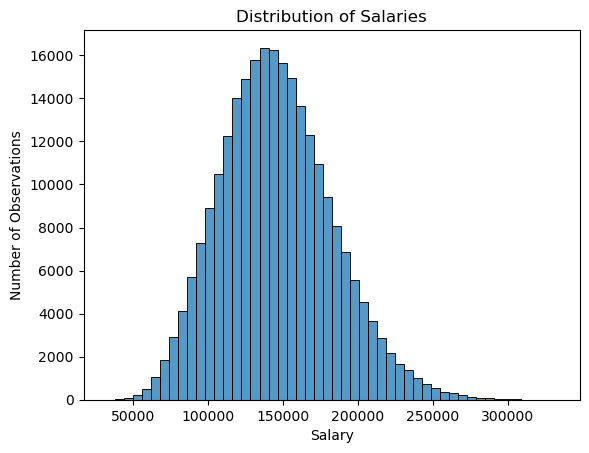

In [32]:
sns.histplot(data=df, x="salary", bins=50)
plt.title("Distribution of Salaries")
plt.xlabel("Salary")
plt.ylabel("Number of Observations")
plt.show()

The histogram shows the overall distribution of salaries. It gives a visual overview of the range and concentration of salary values in the dataset.

##### 1.2 Average salary by department

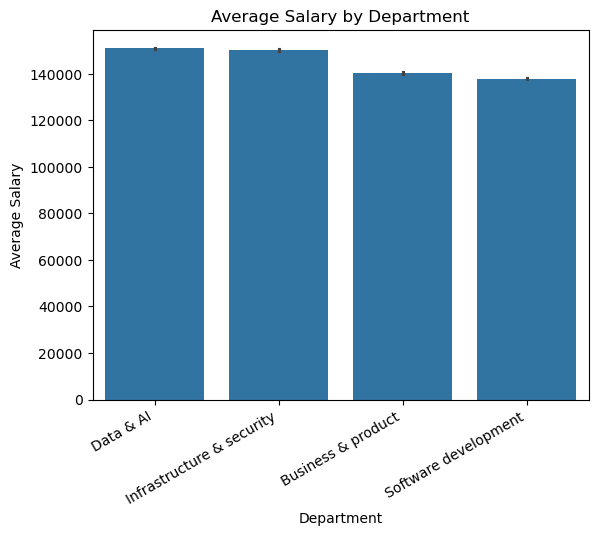

In [33]:
sns.barplot(data=df, x="department", y="salary", order=df.groupby("department")["salary"].mean().sort_values(ascending=False).index)
plt.title("Average Salary by Department")
plt.xlabel("Department")
plt.ylabel("Average Salary")
plt.xticks(rotation=30, ha="right")
plt.show()

The department plot shows that average salary differs across the departments created with the Ollama API.

##### 1.3 Average salary by experience group

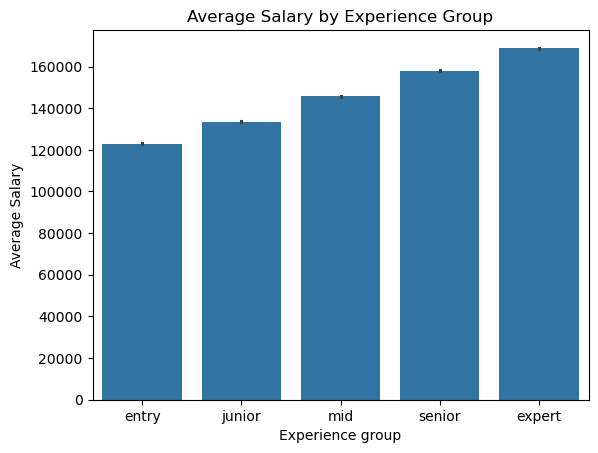

In [34]:
sns.barplot(data=df, x="experience_group", y="salary", order=df.groupby("experience_group")["salary"].mean().sort_values(ascending=True).index)
plt.title("Average Salary by Experience Group")
plt.xlabel("Experience group")
plt.ylabel("Average Salary")
plt.show()

The experience group plot shows that average salary increases across higher experience groups.

##### 1.4 Correlation matrix

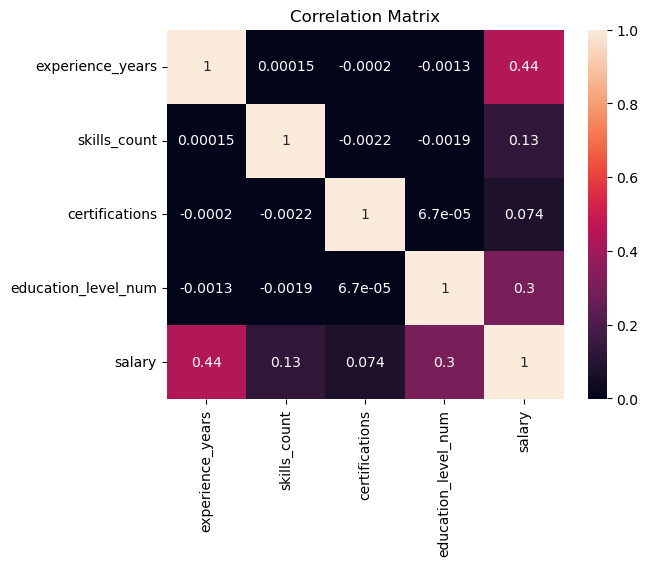

In [35]:
sns.heatmap(correlation_matrix, annot=True)
plt.title("Correlation Matrix")
plt.show()

The heatmap visualizes the correlation matrix and makes it easier to compare the strength of relationships between the numeric variables.

#### Regression analysis

OLS regression is used to examine which variables are associated with salary.

The dependent variable is `salary`. The independent variables include experience, skills, certifications, education level, department, company size, location and remote work arrangement.

Three regression models are estimated:

1. A model with only numeric variables
2. A model that also includes the Ollama-created department variable
3. A fuller model with department, company size, location and remote work arrangement

The purpose is to understand which factors are associated with salary differences in the dataset.

In [36]:
# ols on numerical variables
reg1 = smf.ols(
    formula="""
    salary ~ experience_years
           + skills_count
           + certifications
           + education_level_num
    """,
    data=df
).fit()

print(reg1.summary())

                            OLS Regression Results                            
Dep. Variable:                 salary   R-squared:                       0.307
Model:                            OLS   Adj. R-squared:                  0.307
Method:                 Least Squares   F-statistic:                 2.764e+04
Date:                Sat, 09 May 2026   Prob (F-statistic):               0.00
Time:                        15:53:44   Log-Likelihood:            -2.9414e+06
No. Observations:              250000   AIC:                         5.883e+06
Df Residuals:                  249995   BIC:                         5.883e+06
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept            8.162e+04    

The first regression shows that all numeric variables are positively associated with salary, with the model explaining for approximately 30,7% of the variation in the salary variable. Experience, skills, certifications and education level all have statistically significant p-values below 0.05, meaning they are clearly related to salary in this model.
Experience and education level appear especially important, as their coefficients are larger than the coefficients for skills and certifications. 

In [37]:
# ols on numerical variables + the ollama-created department variable treated as a dummy
reg2 = smf.ols(
    formula="""
    salary ~ experience_years
           + skills_count
           + certifications
           + education_level_num
           + C(department)
    """,
    data=df
).fit()

print(reg2.summary())

                            OLS Regression Results                            
Dep. Variable:                 salary   R-squared:                       0.331
Model:                            OLS   Adj. R-squared:                  0.331
Method:                 Least Squares   F-statistic:                 1.768e+04
Date:                Sat, 09 May 2026   Prob (F-statistic):               0.00
Time:                        15:53:45   Log-Likelihood:            -2.9369e+06
No. Observations:              250000   AIC:                         5.874e+06
Df Residuals:                  249992   BIC:                         5.874e+06
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

After adding the department dummy created with the Ollama LLM, the model explains about 33.1% of the variation in salary. Experience, skills, certifications and education level remain positively associated with salary.

Compared with the reference department "Business & Product", the other departments Data & AI and Infrastructure & Security are associated with higher salaries, while Software Development is associated with a lower salary. All coefficients in this regression are significant even at a 1% level. 

In [38]:
# ols on all variables, with non-numeric treated as dummies
reg3 = smf.ols(
    formula="""
    salary ~ experience_years
           + skills_count
           + certifications
           + education_level_num
           + C(department)
           + C(company_size)
           + C(location)
           + C(remote_work)
    """,
    data=df
).fit()

print(reg3.summary())

                            OLS Regression Results                            
Dep. Variable:                 salary   R-squared:                       0.823
Model:                            OLS   Adj. R-squared:                  0.823
Method:                 Least Squares   F-statistic:                 5.278e+04
Date:                Sat, 09 May 2026   Prob (F-statistic):               0.00
Time:                        15:53:47   Log-Likelihood:            -2.7708e+06
No. Observations:              250000   AIC:                         5.542e+06
Df Residuals:                  249977   BIC:                         5.542e+06
Df Model:                          22                                         
Covariance Type:            nonrobust                                         
                                                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

The full regression model explains about 82.3% of the variation in salary, which is much higher than the earlier simpler models. This suggests that adding company size, location and remote work arrangement improves the model substantially.

Experience, skills, certifications and education level are all positively associated with salary. In other words, higher experience, more skills, more certifications and higher education level are linked with higher salaries in the dataset.

Department also matters. Data & AI and Infrastructure & Security are associated with higher salaries than the reference department, while Software Development is associated with lower salary.

Company size and location have large effects in the model. Smaller company categories are associated with lower salaries than the reference company size. Some locations, such as USA, Canada, UK and Germany, are associated with higher salaries, while India is associated with lower salary.

Some location variables are not statistically significant. Netherlands, Remote, Singapore and Sweden have p-values above 0.05, meaning their salary differences from the reference location are not statistically significant in this model.

Remote work also has mixed results. Remote work “Yes” is positive and statistically significant, suggesting that remote work is associated with higher salary. Remote work “No” is not statistically significant, meaning it does not show a clear salary difference from the reference remote-work category.

Overall, the full model gives the strongest explanation of salary differences, but the results should be interpreted as associations, not causal effects.

In [45]:
# summary table of regressions
reg_results = pd.DataFrame({
    "Model": [
        "Numeric variables",
        "Numeric variables + department",
        "Full model"
    ],
    "R-squared": [
        reg1.rsquared,
        reg2.rsquared,
        reg3.rsquared
    ],
    "Adjusted R-squared": [
        reg1.rsquared_adj,
        reg2.rsquared_adj,
        reg3.rsquared_adj
    ],
    "AIC": [
        reg1.aic,
        reg2.aic,
        reg3.aic
    ]
})

display(reg_results.round(6))

,Model,R-squared,Adjusted R-squared,AIC
0,Numeric variables,0.306613,0.306602,5.882756e+06
1,Numeric variables + department,0.331179,0.331161,5.873744e+06
2,Full model,0.822855,0.822840,5.541637e+06


#### Export cleaned data and results

In [46]:
# Export cleaned dataset

df.to_csv("cleaned_job_salary_data.csv", index=False)

In [47]:
# Export analysis result tables

salary_summary.to_csv("salary_summary.csv", index=False)
salary_by_department.to_csv("salary_by_department.csv")
salary_by_experience_group.to_csv("salary_by_experience_group.csv")
correlation_matrix.to_csv("correlation_matrix.csv")
reg_results.to_csv("regression_results.csv", index=False)
department_df.to_csv("ollama_department_mapping.csv", index=False)

The cleaned dataset, descriptive statistics, correlation matrix, Ollama department mapping and regression results are exported so that the results can be reviewed outside the notebook.

#### Conclusions

The goal of this project was to analyze which factors are associated with salary differences in the dataset.

The Ollama API was used to classify job titles into broader departments, which were then used in the visual, quantitative and regression analysis.

The analysis showed that salaries differ across departments and experience groups. The regressions showed that experience, skills, certifications and education level are positively associated with salary. The full regression model explained salary differences best after adding department, company size, location and remote work.

Overall, the results suggest that salary is related to both individual factors and job-related factors. Because the dataset is very clean and structured, the results should be understood as patterns found in this specific dataset rather than general conclusions about the real job market.
